# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [2]:
set.seed(15)

simulate_data <- function(sample_size) {
    x <- rnorm(sample_size, 0, 1)
    y <- 1 + 2*x + 3*(x^2) + 4*(x^3)+ rnorm(sample_size, 0, 1)
    return(data.frame(x = x, y = y))
}

df <- simulate_data(100)

str(df)

'data.frame':	100 obs. of  2 variables:
 $ x: num  0.259 1.831 -0.34 0.897 0.488 ...
 $ y: num  1.748 39.251 -0.698 9.563 4.235 ...


b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [3]:
library(leaps)

reg <- regsubsets(y ~ poly(x, 3), data = df)
reg.summary <- summary(reg)
reg.summary

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 3), data = df)
3 Variables  (and intercept)
            Forced in Forced out
poly(x, 3)1     FALSE      FALSE
poly(x, 3)2     FALSE      FALSE
poly(x, 3)3     FALSE      FALSE
1 subsets of each size up to 3
Selection Algorithm: exhaustive
         poly(x, 3)1 poly(x, 3)2 poly(x, 3)3
1  ( 1 ) "*"         " "         " "        
2  ( 1 ) "*"         " "         "*"        
3  ( 1 ) "*"         "*"         "*"        

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Based on each criterion, identify the best model size. Report the coefficients of the best model.

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”


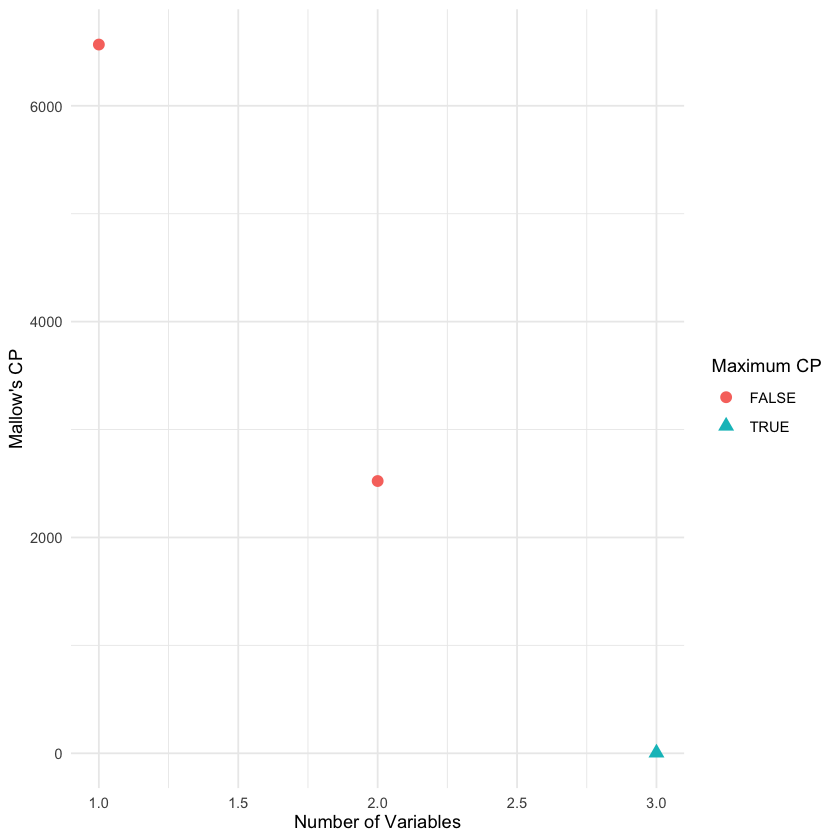

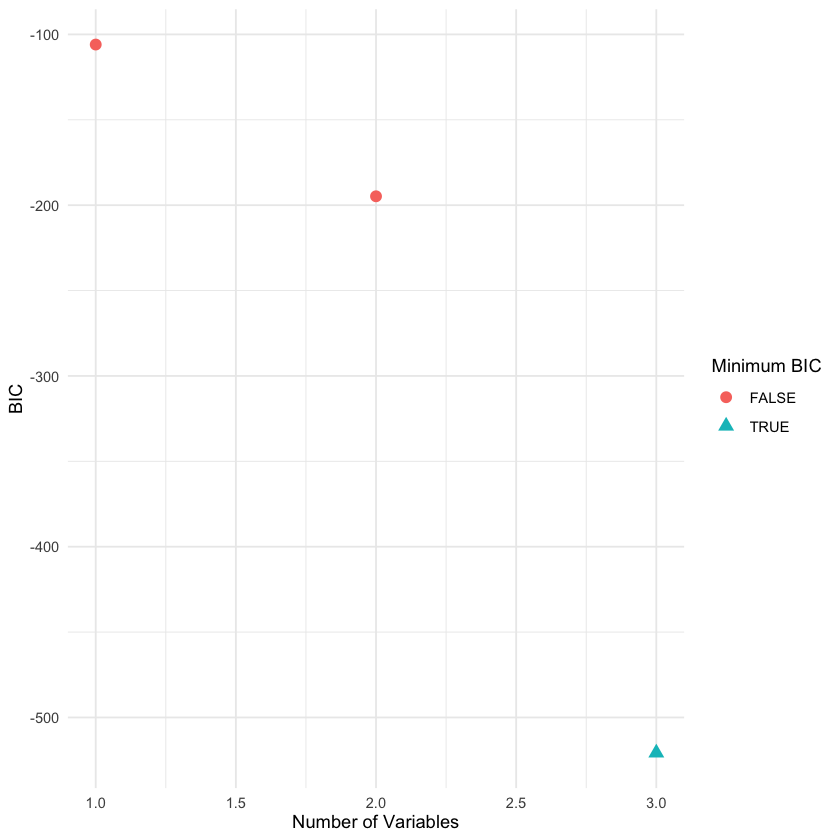

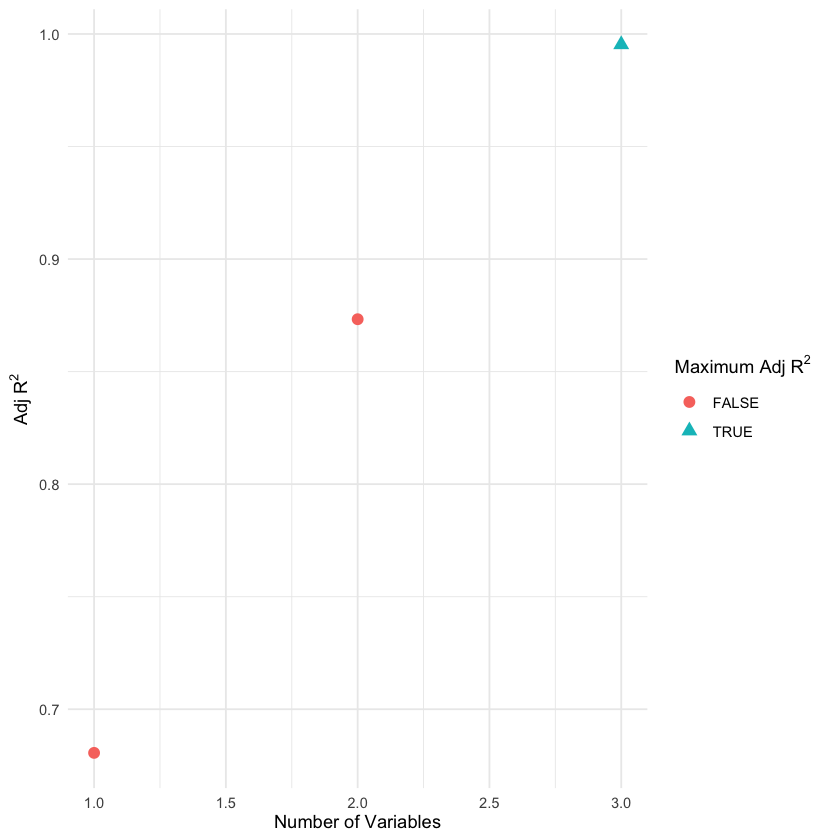

In [4]:
library(ggplot2)

numvar = 1:length(reg.summary$rss)
allfalse = rep(FALSE,length(reg.summary$rss))

##############################           
# mallow's cp
cp_func <- function(numvar, cp){
    cp.df <- data.frame(numvar = numvar, cp <- cp, mincp <- allfalse)
    cp.df$mincp[which.min(cp)] <- TRUE
    x <- ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) + 
    geom_point(size=3) + theme_minimal() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")
    return(x)
}

cp_func(numvar, reg.summary$cp)

##############################             
# bic
bic_func <- function(numvar, bic_val){
 bic.df <- data.frame(numvar = numvar, bic <- bic_val, minbic <- allfalse)
 bic.df$minbic[which.min(bic)] <- TRUE
 x <- ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) + 
     geom_point(size=3) + theme_minimal() +
     labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")
     #which.min(reg.summary$bic) 
     return(x)
}
           
bic_func(numvar, reg.summary$bic)

##############################
# adjr2
adjr2_func <- function(numvar, adjr2){
    adjr2.df <- data.frame(numvar = numvar, adjr2 <- adjr2, maxadjr2 <- allfalse)
    adjr2.df$maxadjr2[which.max(adjr2)] <- TRUE
    x <- ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) + 
    geom_point(size=3) + theme_minimal() + 
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)
    return(x)
    }

adjr2_func(numvar, reg.summary$adjr2)

> The model with all three variables consistently has the lowest BIC, Mallow's CP, and highest R^2. 

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to identify the best model under each criterion. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 3), data = df, method = "forward")
3 Variables  (and intercept)
            Forced in Forced out
poly(x, 3)1     FALSE      FALSE
poly(x, 3)2     FALSE      FALSE
poly(x, 3)3     FALSE      FALSE
1 subsets of each size up to 3
Selection Algorithm: forward
         poly(x, 3)1 poly(x, 3)2 poly(x, 3)3
1  ( 1 ) "*"         " "         " "        
2  ( 1 ) "*"         " "         "*"        
3  ( 1 ) "*"         "*"         "*"        

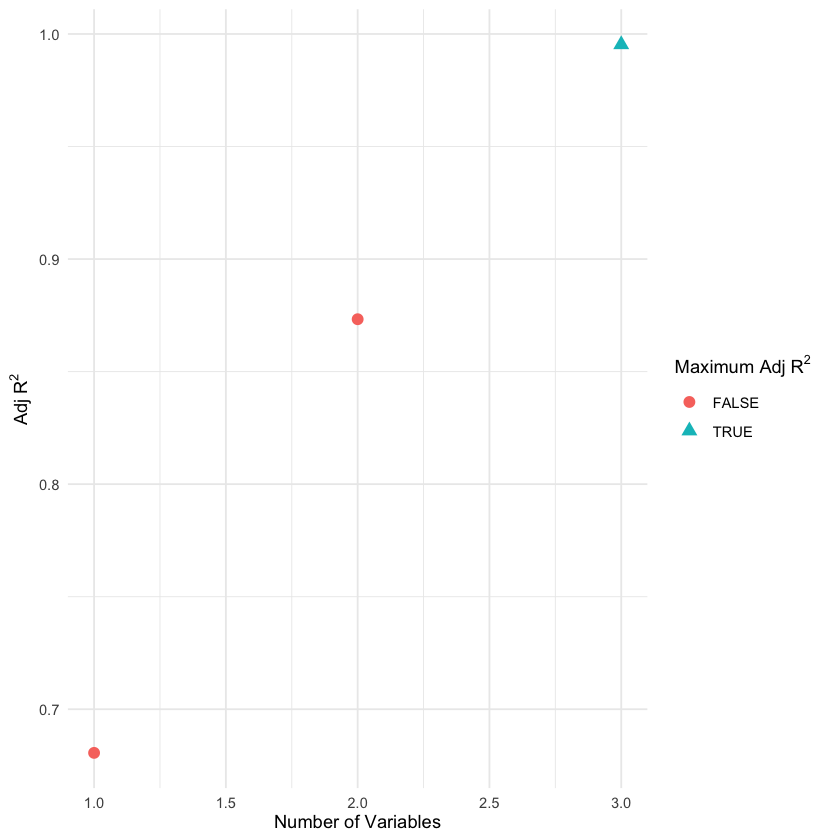

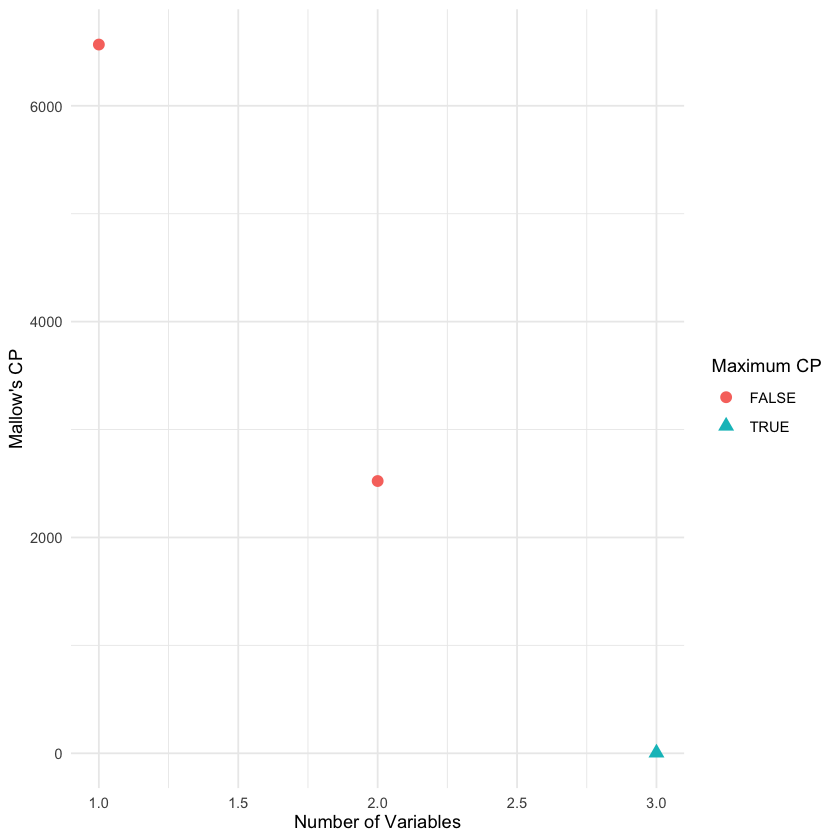

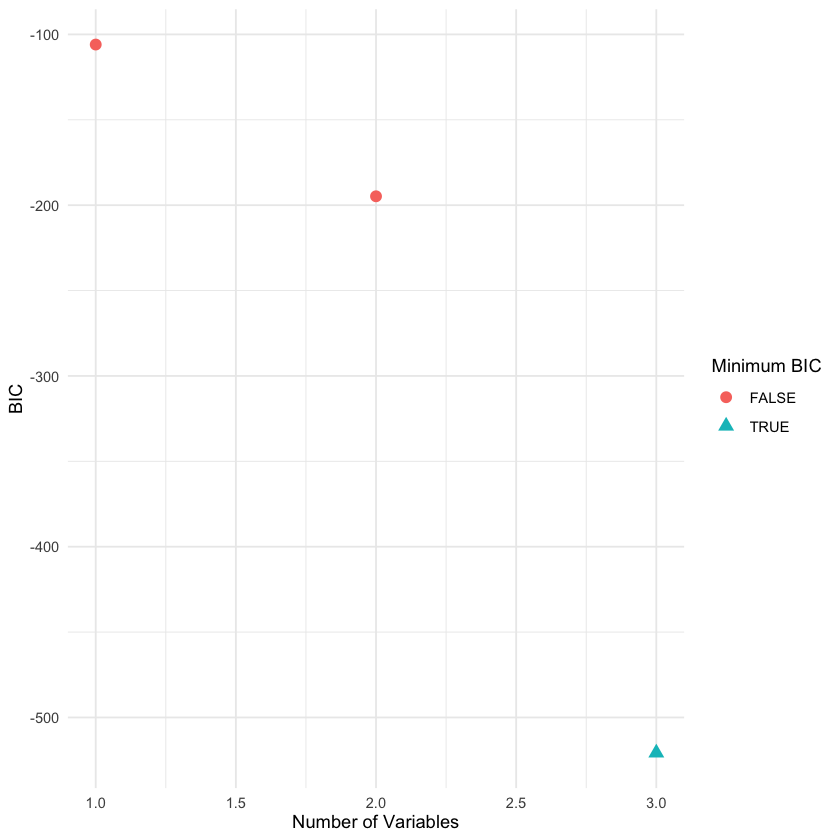

In [6]:
reg <- regsubsets(y ~ poly(x, 3), data = df, method = 'forward')
step_model <- summary(reg)
numvar = 1:length(step_model$rss) 
allfalse = rep(FALSE,length(reg.summary$rss))
summary(reg)

adjr2_func(numvar, step_model$adjr2) 
cp_func(numvar, step_model$cp) 
bic_func(numvar, step_model$bic) 

b) Backwards stepwise selection:

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 3), data = df, method = "backward")
3 Variables  (and intercept)
            Forced in Forced out
poly(x, 3)1     FALSE      FALSE
poly(x, 3)2     FALSE      FALSE
poly(x, 3)3     FALSE      FALSE
1 subsets of each size up to 3
Selection Algorithm: backward
         poly(x, 3)1 poly(x, 3)2 poly(x, 3)3
1  ( 1 ) "*"         " "         " "        
2  ( 1 ) "*"         " "         "*"        
3  ( 1 ) "*"         "*"         "*"        

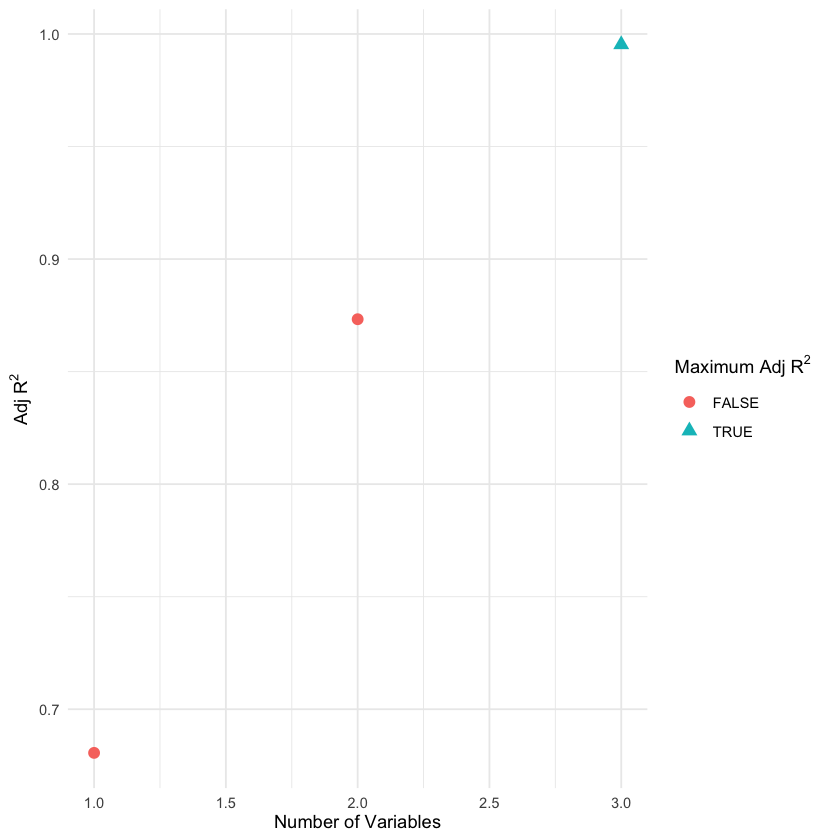

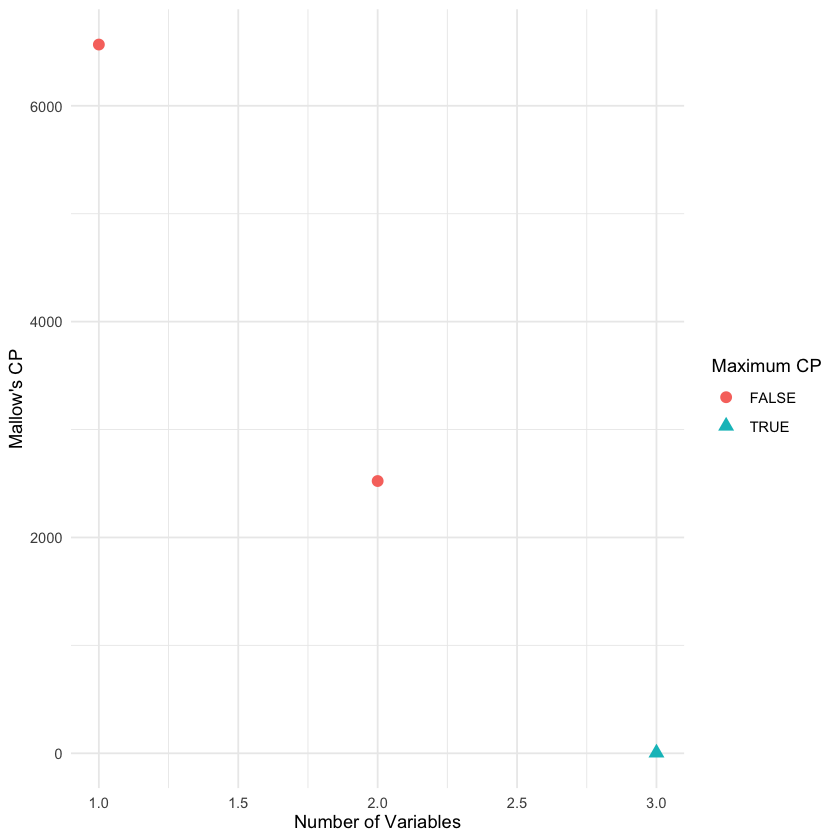

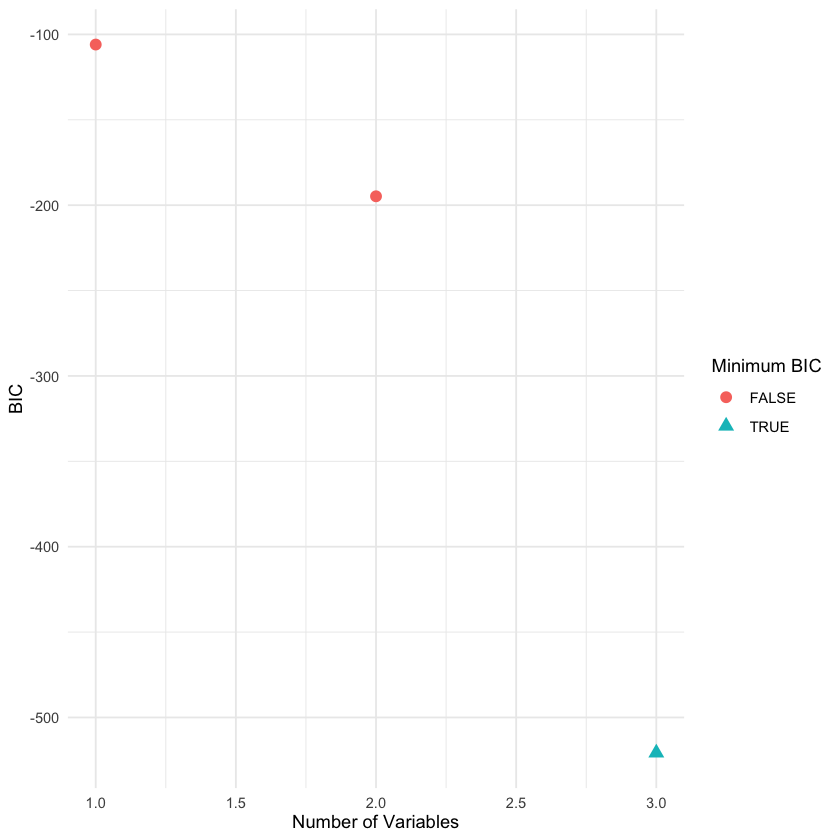

In [7]:
reg <- regsubsets(y ~ poly(x, 3), data = df, method = 'backward')
step_model_back <- summary(reg)
numvar = 1:length(step_model_back$rss) 
allfalse = rep(FALSE,length(step_model_back$rss))
summary(reg)

adjr2_func(numvar, step_model_back$adjr2) 
cp_func(numvar, step_model_back$cp) 
bic_func(numvar, step_model_back$bic) 

c) Compare your results from parts a and b with those of question 1. Did the two methods select similar model sizes and predictors? If not, how did they differ?

> Both the forward and backward selection provide the same variables according to the corresponding model complexity. 

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [8]:
simulate_data <- function(sample_size) {
    p <- 20
    x <- matrix(rnorm(sample_size * p), nrow = sample_size, ncol = p)
    beta <- c(0.1, 0, 0.2, 0, 0.4, 0.3, 0, 4, 5, 6,
    2, 3, 0.7, 0.8, 0.9, 10, 12, 13, 15, 0.11)
    y <- x%*%beta + rnorm(sample_size, 0, 1)
    return(data.frame(x = x, y = y))
}

df <- simulate_data(1000)
train_100 <- sample(1:nrow(df), size = 100)

df_train <- df[train_100, ]        
df_test <- df[-train_100, ] 

str(df)

'data.frame':	1000 obs. of  21 variables:
 $ x.1 : num  0.374 -0.759 1.789 1.208 0.64 ...
 $ x.2 : num  0.984 1.009 -0.337 1.146 -1.183 ...
 $ x.3 : num  -0.3164 -0.0534 -1.8063 0.4214 -0.2402 ...
 $ x.4 : num  -0.7759 1.3635 -1.215 0.5661 -0.0649 ...
 $ x.5 : num  0.872 -0.712 0.238 -1.848 -0.403 ...
 $ x.6 : num  -1.1877 -0.0907 1.1686 -0.6132 1.7094 ...
 $ x.7 : num  0.0826 1.5433 -0.7589 -1.1081 0.064 ...
 $ x.8 : num  0.7408 0.9419 -1.0893 -0.0046 0.8797 ...
 $ x.9 : num  -0.418 -1.69 0.212 0.597 0.284 ...
 $ x.10: num  2.1765 0.0886 0.2287 -1.177 -1.1875 ...
 $ x.11: num  -0.88 0.777 -0.58 1.45 0.276 ...
 $ x.12: num  -0.694 0.937 1.715 -0.357 0.229 ...
 $ x.13: num  -1.597 -0.879 0.607 -0.554 1.254 ...
 $ x.14: num  0.225 1.427 -1.67 0.532 0.868 ...
 $ x.15: num  1.1684 -0.4393 -0.7247 -1.6069 -0.0701 ...
 $ x.16: num  -0.428 1.683 -1.224 -1.692 -0.817 ...
 $ x.17: num  -1.655 1.412 0.787 -0.607 0.664 ...
 $ x.18: num  -0.33 -0.258 0.613 -2.036 1.441 ...
 $ x.19: num  0.445 -0.2

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

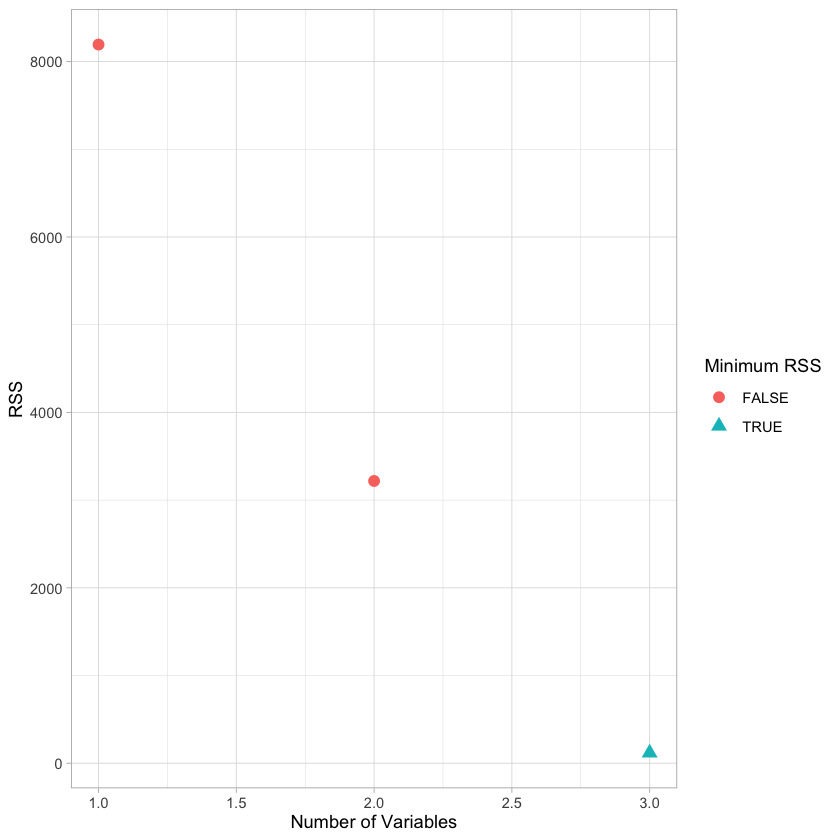

In [11]:
df <- simulate_data(1000)
train_indices <- sample(1:nrow(df), size = 100)

df_train <- df[train_indices, ]
df_test  <- df[-train_indices, ]

reg <- regsubsets(y ~ ., data = df_train, nvmax = 19)

coefi <- coef(reg, id = 19)

test_mat <- model.matrix(y ~ ., data = df_test)
preds <- test_mat[, names(coefi)] %*% coefi

pred_class <- ifelse(preds > 0.5, "pos", "neg")

output <- data.frame(actual = df_test$y, predicted = pred_class)

numvar = 1:length(reg.summary$rss) 
allfalse = rep(FALSE,length(reg.summary$rss))

##############################
# rss
rss.df <- data.frame(numvar = numvar, rss = reg.summary$rss, minrss = allfalse)
rss.df$minrss[which.min(reg.summary$rss)] <- TRUE
ggplot(rss.df,aes(x=numvar,y=rss,shape=minrss,col=minrss)) + 
     geom_point(size=3) + theme_light() + 
     labs(x = "Number of Variables", y = "RSS", color="Minimum RSS", shape="Minimum RSS")

c) Identify the best model according to the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

Best model size (test MSE): 15 
Test MSE: 1.306166 

 (Intercept)          x.2          x.5          x.6          x.8          x.9 
-0.005077769  0.098987257  0.365266531  0.104844078  4.051079432  5.088495029 
        x.10         x.11         x.12         x.13         x.14         x.15 
 5.977447191  2.054638775  2.895166564  0.661973082  0.725160815  0.596408253 
        x.16         x.17         x.18         x.19 
 9.998285488 12.094626697 13.052725070 15.034221562 


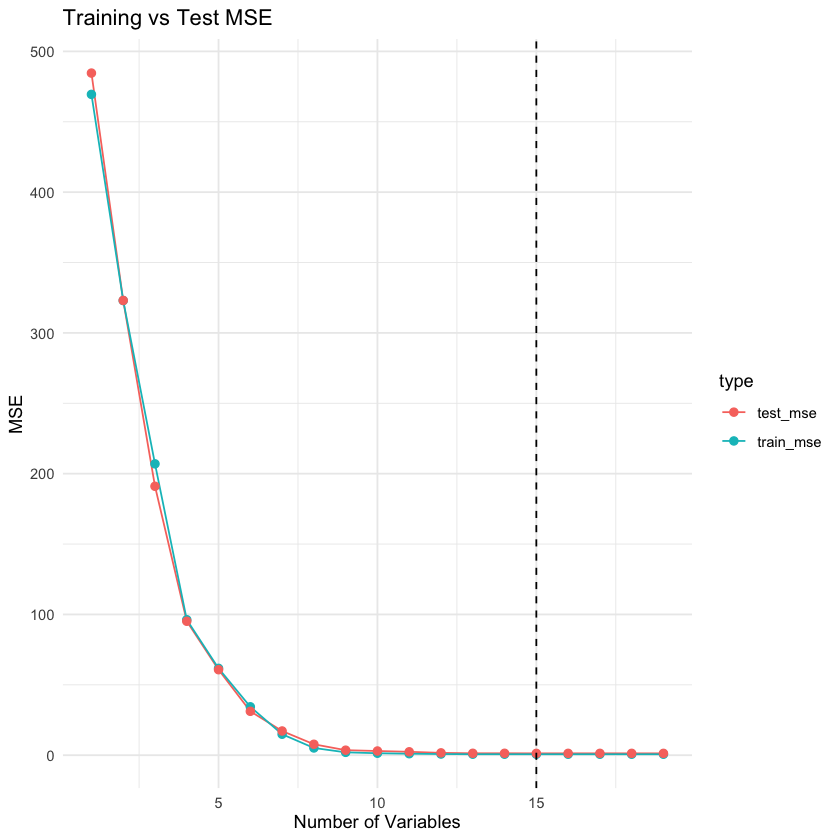

In [12]:
train_mat <- model.matrix(y ~ ., data = df_train)
test_mat  <- model.matrix(y ~ ., data = df_test)

n_models <- 19
train_mse <- rep(NA, n_models)
test_mse  <- rep(NA, n_models)

for (i in 1:n_models) {
  coefi <- coef(reg, id = i)
  
  # training MSE
  train_pred <- train_mat[, names(coefi)] %*% coefi
  train_mse[i] <- mean((df_train$y - train_pred)^2)
  
  # test MSE
  test_pred <- test_mat[, names(coefi)] %*% coefi
  test_mse[i] <- mean((df_test$y - test_pred)^2)
}

mse_df <- data.frame(
  numvar    = 1:n_models,
  train_mse = train_mse,
  test_mse  = test_mse
)

mse_long <- tidyr::pivot_longer(mse_df, cols = c(train_mse, test_mse),
                                names_to = "type", values_to = "mse")

ggplot(mse_long, aes(x = numvar, y = mse, color = type)) +
  geom_line() + 
  geom_point(size = 2) +
  geom_vline(xintercept = which.min(test_mse), linetype = "dashed") +
  theme_minimal() +
  labs(x = "Number of Variables", y = "MSE",
       title = "Training vs Test MSE")

best_size <- which.min(test_mse)
cat("Best model size (test MSE):", best_size, "\n")
cat("Test MSE:", test_mse[best_size], "\n\n")

best_coefs <- coef(reg, id = best_size)
print(best_coefs)

> The best model according to test MSE includes 15 variables. The true model used to simulate the data had 16 non-zero coefficients out of 20 (B3, B4, B7, B20 = 0 or is very small). Ideally, the best subset model should recover those same predictors. Overall, I think the model is doing a good job. Some discrepancy is expected since the training set is small (n=100) relative to p=20.

**DUE:** 11:59pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> I did not collaborate with any of my classmates on this assignment.